> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 5: Updating forecasts as counts arrive

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/05_updating.ipynb)

[Tutorial 4](04_forecasting.ipynb) forecast the moose population after 1988 from a model fit to all the counts.
A forecaster works forward in time instead: each year brings a new count, and the forecast for the next year should use it.
In this tutorial we stand in 1980 and fit the model to the counts of 1967 to 1980.
Then, for each year from 1981 to 1988, we forecast that year's count, observe it, and update the model.
Comparing each forecast with the count that followed tests the forecasts as a forecaster would.

It develops two ideas of [ProbPipe's approach](../index.md#the-approach):

1. **One vocabulary of operations:** each year's update conditions the previous year's result, which is a distribution like any other.
2. **Computation from capabilities:** the same `condition_on` that needed a sampler in tutorial 2 updates a distribution on finitely many points exactly.

The tutorial takes about 25 minutes, and it ends with three exercises.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    Distribution,
    EmpiricalDistribution,
    HalfNormal,
    LogNormal,
    Normal,
    Poisson,
    Weights,
    condition_on,
    conditional_distribution,
    function,
    iterate,
    mean,
    quantile,
    sample,
    with_resampling,
    workflow_run,
)

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The model, fit to 1967 to 1980

This cell repeats tutorial 3's model with process noise and fits it to the first 14 counts, the ones a forecaster in 1980 has.

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
FIRST = 14  # the counts of 1967 to 1980
print("years fit:", years[0], "to", years[FIRST - 1])
print("years forecast:", years[FIRST], "to", years[-1])


def trajectory(r: jax.Array, K: jax.Array, n0: float, shocks: jax.Array) -> jax.Array:
    """The population in each year after the year of *n0*, given each year's shock to the growth."""

    def step(N: jax.Array, shock: jax.Array) -> tuple[jax.Array, jax.Array]:
        N_next = N * jnp.exp(r * (1.0 - N / K) + shock)
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), shocks)
    return N


def ricker_model(years_fit: int) -> Distribution:
    """Tutorial 3's model of the counts of the first *years_fit* years."""
    prior = (
        LogNormal("K", jnp.log(350.0), 0.4)
        * LogNormal("r", jnp.log(0.4), 0.4)
        * Beta("phi", 2.0, 2.0)
        * HalfNormal("sigma", 0.2)
    ).with_label("prior")
    def shocks_given_sigma(sigma: jax.Array) -> Normal:
        return Normal("shocks", jnp.zeros(years_fit), sigma)

    shocks = conditional_distribution(
        "shocks", shocks_given_sigma, given_spec={"sigma": prior.event_spec.components["sigma"]}
    )

    def noisy_counts(
        K: jax.Array, r: jax.Array, phi: jax.Array, shocks: jax.Array, n0: float = 50.0
    ) -> Poisson:
        return Poisson("y", phi * trajectory(r, K, n0, shocks))

    inputs = {name: prior.event_spec.components[name] for name in ["K", "r", "phi"]}
    likelihood = conditional_distribution(
        "counts",
        noisy_counts,
        given_spec={**inputs, "shocks": shocks.event_spec.components["shocks"]},
    )
    return (likelihood * shocks * prior).with_label("model")


with workflow_run(seed=1):
    posterior_1980 = condition_on(ricker_model(FIRST), {"y": counts[:FIRST]})
DRAWS = posterior_1980.num_atoms
print("number of posterior draws:", DRAWS)

years fit: 1967 to 1980
years forecast: 1981 to 1988


number of posterior draws: 4000


## 2. Particles

A forecast for 1981 needs the population of 1980 as well as the parameters.
The population of 1980 is a function of the parameters and the shocks, so we apply that function to the posterior, as tutorial 4 did.
The function returns a record, so its result is a distribution over records, with one per posterior draw.
Each record is a **particle**: a set of parameters together with the population that they imply for 1980.

In [4]:
@function
def state_1980(
    K: jax.Array, r: jax.Array, phi: jax.Array, sigma: jax.Array, shocks: jax.Array
) -> dict[str, jax.Array]:
    population = trajectory(r, K, 50.0, shocks)
    return {"K": K, "r": r, "phi": phi, "sigma": sigma, "N": population[-1]}


with workflow_run(seed=2):
    particles = state_1980.with_options(n_broadcast_samples=DRAWS)(
        posterior_1980["K"],
        posterior_1980["r"],
        posterior_1980["phi"],
        posterior_1980["sigma"],
        posterior_1980["shocks"],
    )
print("fields of a particle:", list(particles.event_spec.components))
print("number of particles:", particles.num_atoms)
print("mean population in 1980:", round(float(mean(particles["N"]))))

fields of a particle: ['K', 'N', 'phi', 'r', 'sigma']
number of particles: 4000
mean population in 1980: 325


The particles are an `EmpiricalDistribution`, like the posterior of tutorial 2: a distribution on finitely many points, its **atoms**, each with a probability called its **weight**.
Here every particle has weight 1/4000.

## 3. Forecasting one year

A forecast moves each particle forward one year: the Ricker step, with a new shock drawn from the shocks' distribution, $\text{Normal}(0, \sigma)$, which is $\sigma$ times a standard normal draw.
The parameters stay as they are.

In [5]:
@function
def grow(
    K: jax.Array,
    r: jax.Array,
    phi: jax.Array,
    sigma: jax.Array,
    N: jax.Array,
    standard_shock: jax.Array,
) -> dict[str, jax.Array]:
    N_next = N * jnp.exp(r * (1.0 - N / K) + sigma * standard_shock)
    return {"K": K, "r": r, "phi": phi, "sigma": sigma, "N": N_next}


standard_shock = Normal("standard_shock", 0.0, 1.0)


def forecast(particles: Distribution) -> EmpiricalDistribution:
    """The particles moved forward one year, each with a new shock."""
    return grow.with_options(n_broadcast_samples=DRAWS)(
        particles["K"],
        particles["r"],
        particles["phi"],
        particles["sigma"],
        particles["N"],
        standard_shock,
    )

## 4. The observation model and the particles

The forecast count follows from the forecast particles through the observation model, $y \sim \text{Poisson}(\phi N)$, a conditional distribution of the count given $\phi$ and $N$.
`observe * particles` composes it with the particles, as `likelihood * prior` composed the model in tutorial 1, and the draws of `y` of the result are forecast counts.

In [6]:
def count_given_state(phi: jax.Array, N: jax.Array) -> Poisson:
    return Poisson("y", phi * N)


observe = conditional_distribution(
    "count",
    count_given_state,
    given_spec={name: particles.event_spec.components[name] for name in ["phi", "N"]},
)


def count_interval(particles: Distribution, level: float = 0.9) -> np.ndarray:
    """The central interval of the forecast count with probability *level*."""
    draws = sample(observe * particles, sample_shape=(4000,))["y"].raw()
    return np.percentile(draws, [50 * (1 - level), 50 * (1 + level)])


with workflow_run(seed=3):
    particles_1981 = forecast(particles)
    low, high = count_interval(particles_1981)
print(f"forecast count for 1981: 90% interval ({low:.0f}, {high:.0f})")
print("observed count for 1981:", int(counts[FIRST]))

forecast count for 1981: 90% interval (138, 234)
observed count for 1981: 198


## 5. An exact update

The count of 1981 updates the particles by Bayes' rule.
`observe * particles_1981` is the joint distribution of the particles and the count, so `condition_on` given the count returns the particles' distribution given it.
It is the call that ran NUTS in tutorial 2:

In [7]:
def update(particles: EmpiricalDistribution, count: jax.Array) -> EmpiricalDistribution:
    """The particles conditioned on *count* by Bayes' rule."""
    return condition_on(observe * particles, {"y": count})


report = condition_on.check(observe * particles_1981, {"y": counts[FIRST]})
print("route:", report.route)
print("method:", report.method)
print("exact:", report.exact)

route: inference_methods
method: empirical_reweighting
exact: True


For a distribution on finitely many points, Bayes' rule multiplies each point's weight by the likelihood of the data at that point and renormalizes, so the result is exact.
`condition_on` selects the exact method `empirical_reweighting`, which returns the same particles with their new weights:

In [8]:
def effective_number(particles: EmpiricalDistribution) -> float:
    """The number of equally weighted particles that the weighted particles are worth."""
    return float(Weights(weights=particles.weights).effective_sample_size)


updated_1981 = update(particles_1981, counts[FIRST])
print("effective number of particles before the update:", round(effective_number(particles_1981)))
print("effective number of particles after the update:", round(effective_number(updated_1981)))
print("mean population in 1981 before the update:", round(float(mean(particles_1981["N"]))))
print("mean population in 1981 after the update:", round(float(mean(updated_1981["N"]))))

effective number of particles before the update: 4000
effective number of particles after the update: 2210
mean population in 1981 before the update: 337
mean population in 1981 after the update: 354


The update moves the population toward the value the count suggests, and it concentrates the weight on the particles that agree with the count.
Each year's update concentrates it further, until a few particles hold all the weight.
**Resampling** prevents that: it draws a new set of particles from the weighted ones, so a heavy particle appears several times and a light one disappears, and then gives every particle the same weight.
`with_resampling(step, ess_threshold=0.5)` resamples whenever the effective number falls below half the number of particles.

## 6. Every year in turn

One step of the forecaster's year is a forecast and then an update.
`iterate(step, initial, inputs)` applies `step` to the particles and each count in turn, and returns a batch of the particles after each year, starting with 1980's.

In [9]:
def step(particles: EmpiricalDistribution, count: jax.Array) -> EmpiricalDistribution:
    return update(forecast(particles), count)


with workflow_run(seed=4):
    filtered = iterate(with_resampling(step, ess_threshold=0.5), particles, list(counts[FIRST:]))
filtered_years = years[FIRST - 1 :]
print("kind of result:", type(filtered).__name__)
print("number of years held:", filtered.batch_shape[0])

bands = np.array([quantile(filtered[t]["N"], jnp.array([0.05, 0.5, 0.95])).raw() for t in range(len(filtered_years))])
for year, (low, median, high) in zip(filtered_years, bands):
    print(f"{year}: median population {median:.0f}, 90% interval ({low:.0f}, {high:.0f})")

kind of result: DistributionBatch
number of years held: 9


1980: median population 318, 90% interval (234, 439)
1981: median population 346, 90% interval (260, 473)
1982: median population 428, 90% interval (330, 593)
1983: median population 424, 90% interval (327, 578)
1984: median population 412, 90% interval (312, 557)
1985: median population 367, 90% interval (276, 501)
1986: median population 467, 90% interval (362, 650)
1987: median population 432, 90% interval (330, 585)
1988: median population 451, 90% interval (348, 608)


`filtered[t]` is the distribution of the particles after the update of year $1980 + t$, and the population they hold tracks the counts as they arrive.

## 7. How good were the forecasts?

The forecast of each year's count comes from the particles of the year before, which have seen every count up to then and none after.
A forecast interval of 90% should hold about 90% of the counts.

counts inside their 90% forecast interval: 6 of 8


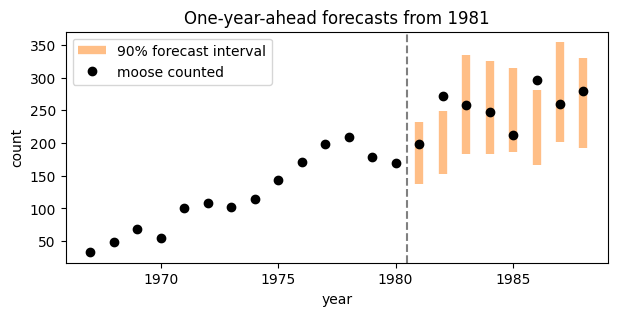

In [10]:
observed_counts = np.asarray(counts[FIRST:])
with workflow_run(seed=5):
    intervals = np.array([count_interval(forecast(filtered[t])) for t in range(len(filtered_years) - 1)])
inside = (observed_counts >= intervals[:, 0]) & (observed_counts <= intervals[:, 1])
print("counts inside their 90% forecast interval:", int(inside.sum()), "of", len(observed_counts))

forecast_years = years[FIRST:]
fig, ax = plt.subplots(figsize=(7, 3))
ax.vlines(forecast_years, intervals[:, 0], intervals[:, 1], color="tab:orange", lw=6, alpha=0.5, label="90% forecast interval")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.axvline(years[FIRST - 1] + 0.5, color="gray", ls="--")
ax.set(xlabel="year", ylabel="count", title="One-year-ahead forecasts from 1981")
ax.legend(loc="upper left")
plt.show()

With eight forecasts, a coverage between six and eight of eight agrees with the nominal 90%.

## 8. The particles of 1988 and a fit to all the counts

After the update of 1988 the particles have seen every count, as the posterior of tutorial 3 did.
If the updates are accurate, the two agree.

In [11]:
with workflow_run(seed=6):
    posterior_1988 = condition_on(ricker_model(counts.shape[0]), {"y": counts})

final = filtered[len(filtered_years) - 1]
for name in ["K", "r", "phi", "sigma"]:
    print(
        f"{name}: mean {float(mean(final[name])):.3f} from the particles,"
        f" {float(mean(posterior_1988[name])):.3f} from the fit to all the counts"
    )

K: mean 428.401 from the particles, 442.006 from the fit to all the counts
r: mean 0.277 from the particles, 0.286 from the fit to all the counts
phi: mean 0.613 from the particles, 0.593 from the fit to all the counts
sigma: mean 0.126 from the particles, 0.126 from the fit to all the counts


The means agree to within about 5%.
The particles' parameters are never redrawn, only reweighted and resampled, so the particles hold fewer and fewer distinct values:

In [12]:
distinct_K = [len(np.unique(np.asarray(filtered[t].atoms["K"].raw()))) for t in range(len(filtered_years))]
print("distinct values of K among the particles of 1980:", distinct_K[0])
print("distinct values of K among the particles of 1988:", distinct_K[-1])

distinct values of K among the particles of 1980: 3992
distinct values of K among the particles of 1988: 138


Over a longer series they would collapse onto a few values, so a filter for many years adds a step that moves the particles, such as a few MCMC steps after each resampling.

## Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** Print the effective number of particles after each update, by applying `step` without `with_resampling`.
In which year does it fall below half the number of particles?

In [13]:
# @title Solution
with workflow_run(seed=7):
    unresampled = iterate(step, particles, list(counts[FIRST:]))
for t, year in enumerate(filtered_years[1:], start=1):
    print(f"{year}: effective number of particles {effective_number(unresampled[t]):.0f}")

1981: effective number of particles 2254
1982: effective number of particles 112
1983: effective number of particles 52
1984: effective number of particles 19
1985: effective number of particles 7
1986: effective number of particles 6
1987: effective number of particles 5
1988: effective number of particles 3


**Exercise 2.** Forecast two years ahead instead of one: from the particles of each year, forecast the count of the year after next, and count how many of those intervals hold their counts.

In [14]:
# @title Solution
two_year = []
with workflow_run(seed=8):
    for t in range(len(filtered_years) - 2):
        two_year.append(count_interval(forecast(forecast(filtered[t]))))
two_year = np.array(two_year)
later = np.asarray(counts[FIRST + 1 :])
held = (later >= two_year[:, 0]) & (later <= two_year[:, 1])
print("counts inside their two-year 90% forecast interval:", int(held.sum()), "of", len(later))
widths = intervals[:, 1] - intervals[:, 0]
print("mean width of the one-year intervals:", round(float(np.mean(widths))))
print("mean width of the two-year intervals:", round(float(np.mean(two_year[:, 1] - two_year[:, 0]))))

counts inside their two-year 90% forecast interval: 6 of 7
mean width of the one-year intervals: 127
mean width of the two-year intervals: 153


**Exercise 3.** The forecasts above use 90% intervals.
Compute the 50% intervals with `count_interval(..., level=0.5)` and count how many of the eight counts they hold.
How many would you expect?

In [15]:
# @title Solution
with workflow_run(seed=9):
    halves = np.array(
        [count_interval(forecast(filtered[t]), level=0.5) for t in range(len(filtered_years) - 1)]
    )
held = (observed_counts >= halves[:, 0]) & (observed_counts <= halves[:, 1])
print("counts inside their 50% forecast interval:", int(held.sum()), "of", len(observed_counts))
print("expected number:", 0.5 * len(observed_counts))

counts inside their 50% forecast interval: 5 of 8
expected number: 4.0


## Summary

- Particles represent a posterior as weighted points, each holding the parameters and the current state, and they are an `EmpiricalDistribution` like the posterior they came from.
- A forecast moves each particle forward with a new shock, and an update conditions the particles on the new count with `condition_on`, which reweights them exactly by Bayes' rule.
- `iterate` runs the forecast and the update for each year, and `with_resampling` resamples when the weights concentrate.
- The one-year-ahead forecast intervals test the model as a forecaster uses it, and the particles of 1988 agree with a fit to all the counts.

## References

- Doucet, A., de Freitas, N., and Gordon, N. (2001). An introduction to sequential Monte Carlo methods. In *Sequential Monte Carlo Methods in Practice*, Springer.
- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. It describes particle filters for ecological forecasts.